In [6]:
!pip install keras
!pip install tensorflow

In [7]:
import numpy as np
from keras.datasets import mnist
import matplotlib.pyplot as plt

In [8]:
# Load MNIST data
print('Loading data...')
(x_train, _), (x_test, y_test) = mnist.load_data()
x_train = x_train[:1000]

Loading data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [9]:
# Normalize and flatten the data
x_train = x_train.astype('float32') / 255.
print('x_train shape:', x_train.shape)
x_train = x_train.reshape((len(x_train), -1))  # Flatten each 28x28 image into a 784-dimensional vector
print('x_train reshaped:', x_train.shape)

x_test = x_test.astype('float32') / 255.
x_test = x_test.reshape((len(x_test), -1))  # Flatten each 28x28 image into a 784-dimensional vector

x_train shape: (1000, 28, 28)
x_train reshaped: (1000, 784)


In [15]:
# Define the model
class SOM:
    def __init__(self, m, n, dim, epochs, alpha, sigma):
        # Initialize the dimensions of the grid, input dimension, learning parameters
        # Number of rows in the SOM
        # Number of columns in the SOM
        # Dimension of the input vectors
        self.epochs = epochs  # Number of iterations for training
        self.alpha = alpha  # Initial learning rate
        self.sigma = sigma  # Initial neighborhood radius
        self.weights = np.random.random((m * n, dim))  # Initialize weights randomly
        self.m = m
        self.n = n
    def find_bmu(self, x):
        # Find the best matching unit for a given vector, x
        bmu_index = np.argmin(np.linalg.norm(self.weights - x, axis=1))  # Index of the BMU
        return np.array([bmu_index // self.n, bmu_index % self.n])

    def update_weights(self, x, bmu, t):
        # Update the weights of the SOM neurons
        learning_rate = self.alpha * np.exp(-t / self.epochs)  # Decay learning rate
        sigma_decay = self.sigma * np.exp(-t / self.epochs)  # Decay neighborhood radius
        for i in range(self.m):
            for j in range(self.n):
                neuron_pos = np.array([i, j])
                distance = np.linalg.norm(neuron_pos - bmu)  # Calculate distance from BMU
                if distance <= sigma_decay:
                    influence = np.exp(-distance**2 / (2 * sigma_decay**2))  # Calculate influence
                    self.weights[i*self.n+j] += learning_rate * influence * (x - self.weights[i*self.n+j])  # Update weights

    def train(self, data):
        # Train the SOM with the given data
        for epoch in range(self.epochs):
            if epoch % 10 == 0:
              print(f"Training epoch {epoch}/{self.epochs}")
            for x in data:
                bmu = self.find_bmu(x)  # Find the BMU for each sample
                self.update_weights(x, bmu, epoch)  # Update weights based on the BMU

    def map_vects(self, data):
        # Map each input vector to the closest neuron in the SOM grid
        bmu_list = []
        for x in data:
            bmu = self.find_bmu(x)
            bmu_list.append(bmu)
        return bmu_list

In [16]:
# SOM parameters
som = SOM(m=20, n=20, dim=784, epochs=10, alpha=0.3, sigma=10.0)

In [17]:
# Train SOM
print("Starting training...")
som.train(x_train)
print("Training completed.")

Starting training...
Training epoch 0/10
Training completed.


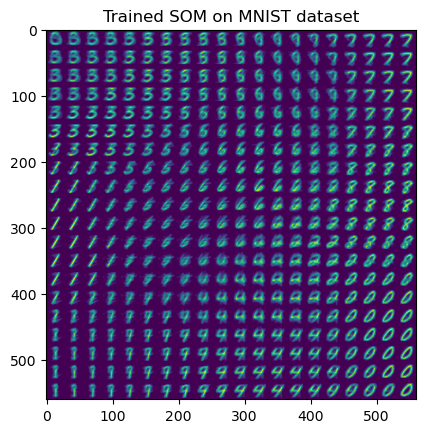

In [18]:
# Visualize the trained SOM
plt.imshow(som.weights.reshape(20, 20, 28, 28).transpose(0, 2, 1, 3).reshape(20*28, 20*28))
plt.title('Trained SOM on MNIST dataset')
plt.show()

In [19]:
# Define a function to visualize the test sample and its mapping on SOM
def visualize_test_sample(test_sample, label, mapped_position, som_weights):
    plt.figure(figsize=(10, 5))

    # Display the test sample image
    plt.subplot(1, 2, 1)
    plt.imshow(test_sample.reshape(28, 28), cmap='gray')
    plt.title(f"Test Sample (Digit: {label})")
    plt.axis('off')

    # Display the SOM and mark the position of the test sample
    plt.subplot(1, 2, 2)
    plt.imshow(som_weights.reshape(20, 20, 28, 28).transpose(0, 2, 1, 3).reshape(20*28, 20*28))
    plt.title('SOM with Test Sample Mapped')
    plt.scatter(mapped_position[1]*28 + 14, mapped_position[0]*28 + 14, color='red', s=50)  # Mark the position
    plt.axis('off')

    plt.show()

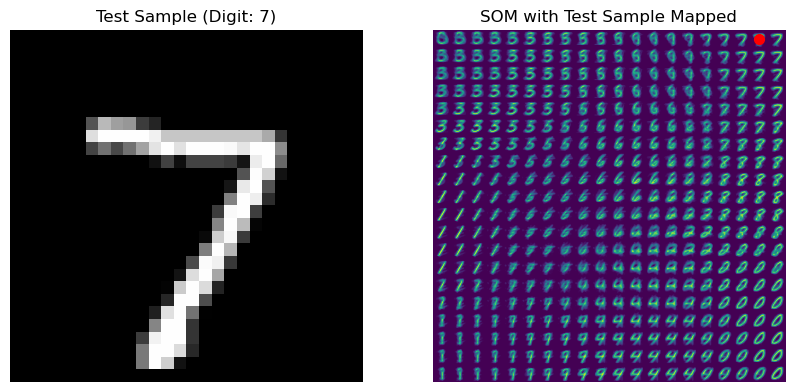

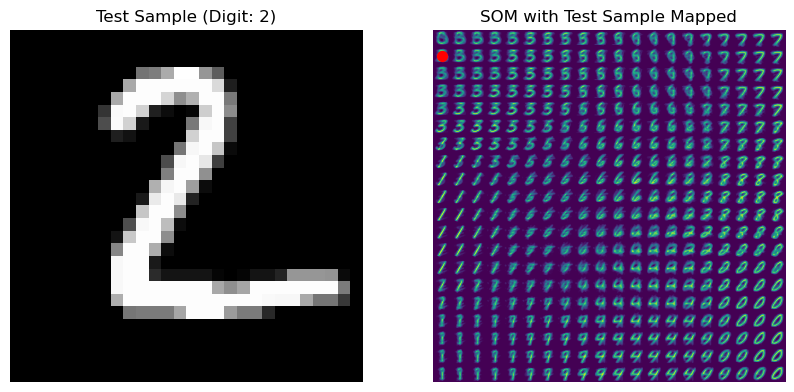

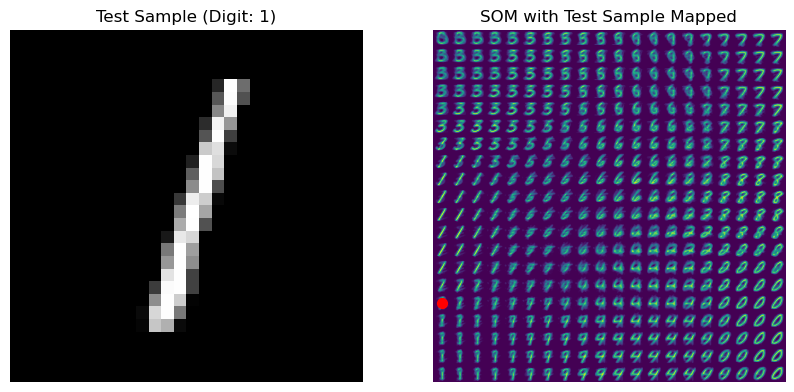

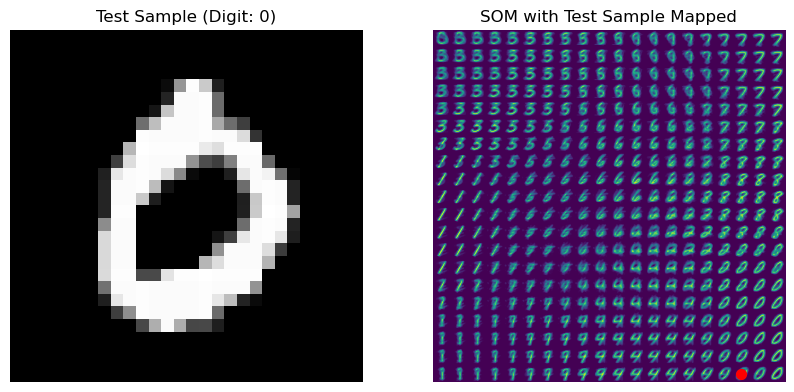

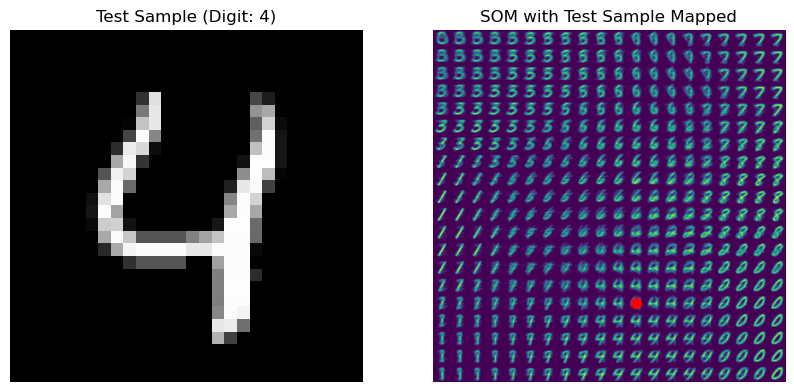

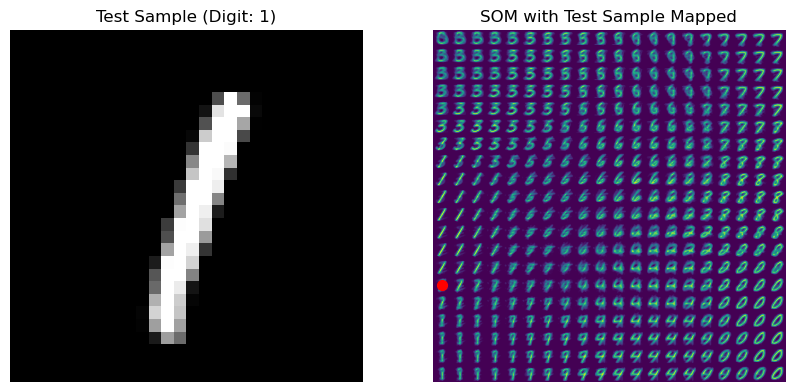

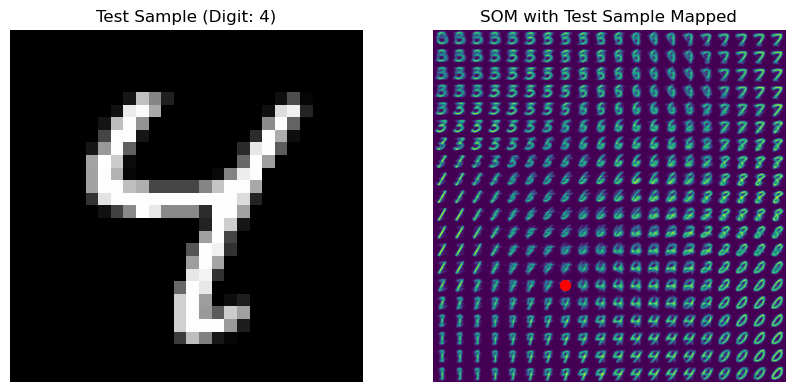

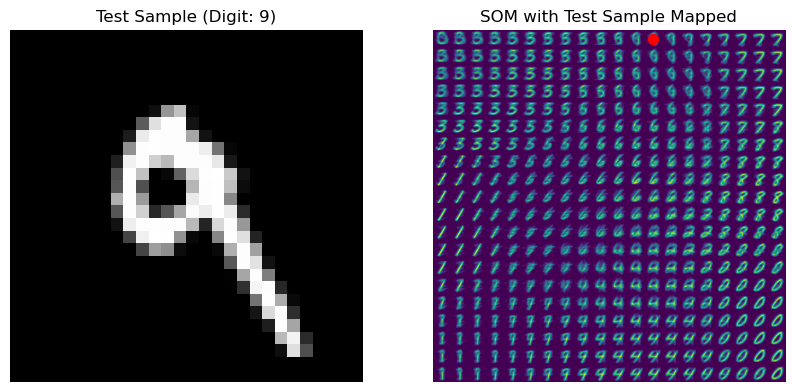

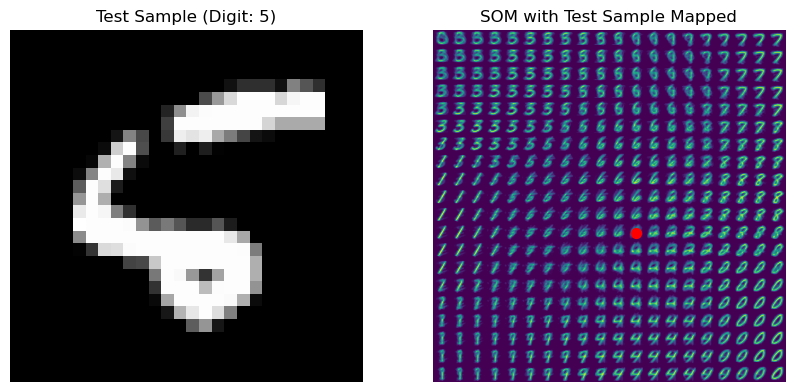

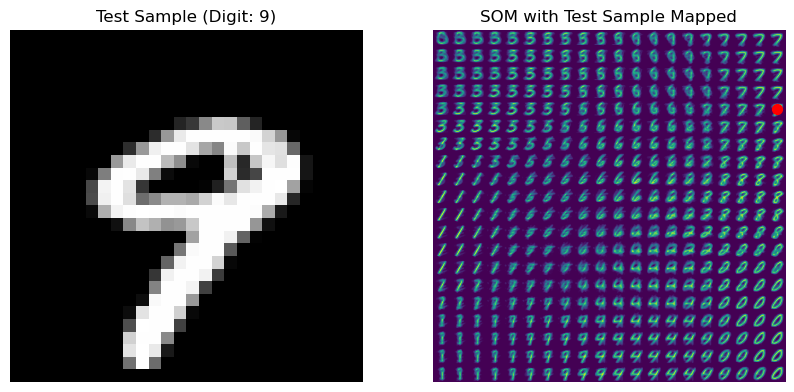

In [20]:
# Evaluate and visualize a few test samples
test_samples = 10  # Number of test samples to evaluate
for i in range(test_samples):
    test_sample = x_test[i]
    test_label = y_test[i]
    mapped_position = som.map_vects([test_sample])[0]
    visualize_test_sample(test_sample, test_label, mapped_position, som.weights)